🔥 SVM (Support Vector Machine) Example

1. 📊 Generating Sample Data...
Training samples: 140
Test samples: 60
Features: 2
Classes: 2

2. 🔧 Data Preprocessing...
✅ Features scaled using StandardScaler
Before scaling - Mean: 0.65, Std: 1.35
After scaling - Mean: -0.00, Std: 1.00

3. 🤖 Training SVM Models...

📈 Linear SVM:
Accuracy: 0.867
Support Vectors: 59

🎯 RBF (Gaussian) SVM:
Accuracy: 0.850
Support Vectors: 62

📐 Polynomial SVM:
Accuracy: 0.750
Support Vectors: 80

4. 📊 Creating Visualizations...


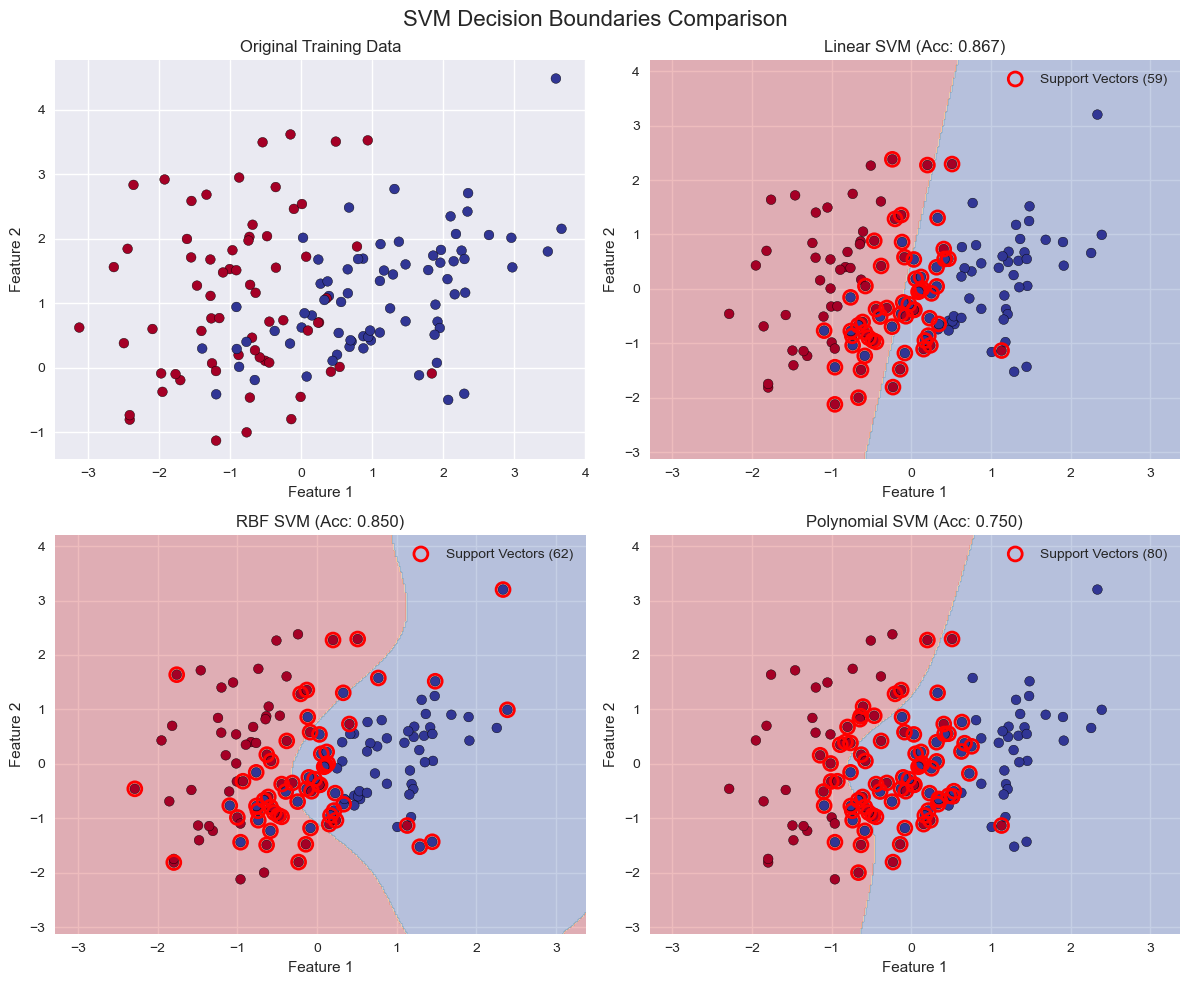


5. 🔍 Detailed Analysis (RBF SVM):

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85        34
           1       0.76      0.96      0.85        26

    accuracy                           0.85        60
   macro avg       0.86      0.86      0.85        60
weighted avg       0.87      0.85      0.85        60


Model Parameters:
C (Regularization): 1.0
Gamma: scale
Kernel: rbf

Support Vector Analysis:
Total Support Vectors: 62
Support Vectors per class: [32 30]
Percentage of data as SV: 44.3%

6. ⚙️ Hyperparameter Tuning Example:
Searching best parameters...
Best parameters: {'C': 1, 'gamma': 0.1}
Best cross-validation score: 0.864
Test accuracy with best params: 0.867

🎯 KEY TAKEAWAYS FOR STUDENTS:
1. 📏 ALWAYS scale your features before using SVM!
2. 🎯 RBF kernel often works well for non-linear problems
3. 🔧 Hyperparameter tuning (C, gamma) is crucial
4. 📊 Support Vectors are the 'difficult' points near boundar

In [1]:
# SVM Example for Students
# A comprehensive example showing SVM basics with visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" SVM (Support Vector Machine) Example")
print("=" * 50)

# 1. Generate sample data
print("\n1.  Generating Sample Data...")
# Create a simple 2D dataset
X, y = datasets.make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y))}")

# 2. Data preprocessing
print("\n2.  Data Preprocessing...")
# Feature scaling (VERY IMPORTANT for SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled using StandardScaler")
print(f"Before scaling - Mean: {X_train.mean():.2f}, Std: {X_train.std():.2f}")
print(f"After scaling - Mean: {X_train_scaled.mean():.2f}, Std: {X_train_scaled.std():.2f}")

# 3. Train different SVM models
print("\n3.  Training SVM Models...")

# Linear SVM
print("\n Linear SVM:")
svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy: {accuracy_linear:.3f}")
print(f"Support Vectors: {len(svm_linear.support_vectors_)}")

# RBF SVM
print("\n RBF (Gaussian) SVM:")
svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy: {accuracy_rbf:.3f}")
print(f"Support Vectors: {len(svm_rbf.support_vectors_)}")

# Polynomial SVM
print("\n Polynomial SVM:")
svm_poly = svm.SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy: {accuracy_poly:.3f}")
print(f"Support Vectors: {len(svm_poly.support_vectors_)}")

# 4. Visualization function
def plot_svm_decision_boundary(X, y, model, title, ax):
    """Plot SVM decision boundary and support vectors"""
    
    # Create a mesh to plot the decision boundary
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black')
    
    # Highlight support vectors
    if hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                  s=100, facecolors='none', edgecolors='red', linewidth=2,
                  label=f'Support Vectors ({len(model.support_vectors_)})')
        ax.legend()
    
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# 5. Create visualizations
print("\n4.  Creating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('SVM Decision Boundaries Comparison', fontsize=16)

# Plot original data
axes[0, 0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', edgecolors='black')
axes[0, 0].set_title('Original Training Data')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')

# Plot SVM results
plot_svm_decision_boundary(X_train_scaled, y_train, svm_linear, 
                          f'Linear SVM (Acc: {accuracy_linear:.3f})', axes[0, 1])
plot_svm_decision_boundary(X_train_scaled, y_train, svm_rbf, 
                          f'RBF SVM (Acc: {accuracy_rbf:.3f})', axes[1, 0])
plot_svm_decision_boundary(X_train_scaled, y_train, svm_poly, 
                          f'Polynomial SVM (Acc: {accuracy_poly:.3f})', axes[1, 1])

plt.tight_layout()
plt.show()

# 6. Detailed analysis of the best model
print("\n5.  Detailed Analysis (RBF SVM):")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

print(f"\nModel Parameters:")
print(f"C (Regularization): {svm_rbf.C}")
print(f"Gamma: {svm_rbf.gamma}")
print(f"Kernel: {svm_rbf.kernel}")

print(f"\nSupport Vector Analysis:")
print(f"Total Support Vectors: {len(svm_rbf.support_vectors_)}")
print(f"Support Vectors per class: {svm_rbf.n_support_}")
print(f"Percentage of data as SV: {len(svm_rbf.support_vectors_)/len(X_train_scaled)*100:.1f}%")

# 7. Hyperparameter tuning example
print("\n6.  Hyperparameter Tuning Example:")
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

print("Searching best parameters...")
grid_search = GridSearchCV(
    svm.SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

# Test the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test accuracy with best params: {accuracy_best:.3f}")

# 8. Key takeaways
print("\n" + "="*50)
print(" KEY TAKEAWAYS FOR STUDENTS:")
print("="*50)
print("1.  ALWAYS scale your features before using SVM!")
print("2.  RBF kernel often works well for non-linear problems")
print("3.  Hyperparameter tuning (C, gamma) is crucial")
print("4.  Support Vectors are the 'difficult' points near boundary")
print("5.  SVM stores support vectors - memory grows with data")
print("6.  SVM can be slow on very large datasets")
print("7.  Different kernels capture different patterns")
print("="*50)